# Customer Churn Prediction

**Goal:** predict which customers will place **no order in the next 60 days**, so that Growth Marketing can target them with retention offers before they go inactive.

**Approach:**
1. **Churn label:** one cut-off date and one row per customer
2. **Features:** a small set of customer-level features built from orders before the cut-off
3. **Model training:** 4 classifiers compared against a baseline
4. **Evaluation:** confusion matrix, ROC curves, top churn drivers, saved model and scores
5. **RFM segments:** rule-based customer segments for the Power BI dashboard

The functions used here are in `src/model_churn.py`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

In [ ]:
sys.path.append(os.path.abspath('../src'))
from model_churn import (
    load_orders, build_churn_dataset, split_data, build_preprocessor, get_models,
    train_and_compare, pick_best_model, get_top_drivers, score_customers, save_outputs,
    CANDIDATE_NUMERIC, NUMERIC_FEATURES, CATEGORICAL_FEATURES, CHURN_WINDOW_DAYS, RANDOM_STATE
)

## Step 1: Churn Label

The data has no churn column, so the label is created from the order dates.

### Why not "days since last order > 60" on the last date of the data?
This is the quickest option, but it has two problems:
- It describes what **already happened**, whereas the PRD asks who is **likely to stop ordering in the next 60 days**.
- The label comes from the customer's recent orders, and those same orders are counted in features such as `OrderCount`. The model then partly sees the answer (target leakage) and gets a score that looks good but means nothing.

### Cut-off date approach
We step back 60 days from the last order date and use that as the **cut-off date**

- **Customers:** everyone who placed at least one order on or before the cut-off
- **Features:** built only from orders on or before the cut-off
- **Label:** `Churn = 1` if the customer places no order in the 60 days after the cut-off

This keeps the features in the past and the label in the future, which is exactly how the model would be used in practice.

### 1.1 Loading orders
`load_orders` reads the cleaned orders and adds the per-order flags used later (late, failed, coupon, COD, rating, peak hour, weekend).

In [4]:
orders = load_orders()

print("Orders:", orders.shape)
print("Customers with orders:", orders['CustomerID'].nunique())
print("Order date range:", orders['OrderDate'].min().date(), "to", orders['OrderDate'].max().date())

Orders: (20475, 24)
Customers with orders: 9827
Order date range: 2023-01-01 to 2024-12-31


### 1.2 How often do customers reorder?
This tells us what share of customers we can expect to come back within 60 days.

In [5]:
order_gaps = (
    orders.sort_values(['CustomerID', 'OrderDate'])
    .groupby('CustomerID')['OrderDate']
    .diff()
    .dt.days
    .dropna()
)

print(f"Orders per customer : {orders.groupby('CustomerID').size().mean():.2f} on average over 24 months")
print(f"Days between orders : median {np.percentile(order_gaps, 50):.0f} "
      f"| 25th pct {np.percentile(order_gaps, 25):.0f} | 75th pct {np.percentile(order_gaps, 75):.0f}")
print(f"Repeat orders placed within {CHURN_WINDOW_DAYS} days : {(order_gaps <= CHURN_WINDOW_DAYS).mean():.1%}")

Orders per customer : 2.08 on average over 24 months
Days between orders : median 142 | 25th pct 63 | 75th pct 268
Repeat orders placed within 60 days : 24.2%


### 1.3 Building the churn dataset

In [6]:
churn_df, cutoff = build_churn_dataset(orders)

print("Cut-off date:", cutoff.date())
print("Customers:", len(churn_df))
print(f"Churn rate: {churn_df['Churn'].mean():.1%}")
churn_df.head()

Cut-off date: 2024-11-01
Customers: 9488
Churn rate: 87.2%


,CustomerID,RecencyDays,TenureDays,OrderCount,AvgOrderValue,LateRate,FailedOrderRate,AvgDeliveryTime,AvgRating,NegativeFeedbackRate,CouponUsageRate,CODShare,PeakHourShare,WeekendShare,Age,Gender,Membership,Region,TotalSpend,Churn
0,1,556,556,1,744.500,0.0,1.000000,NaN,NaN,NaN,0.0,0.0,0.000000,0.000000,35,Male,Basic,West,744.50,1
1,2,302,473,2,405.475,0.0,0.500000,28.0,4.833333,0.0,0.5,0.5,0.000000,0.000000,29,Male,Zomato Pro,South,810.95,1
2,3,19,175,2,483.250,0.5,0.000000,56.5,4.166667,0.0,0.5,0.0,0.500000,0.500000,26,Other,Gold,West,966.50,1
3,6,180,392,3,377.600,0.0,0.333333,35.0,1.833333,1.0,0.0,0.0,0.666667,0.666667,30,Other,Basic,South,1132.80,1
4,7,437,437,1,664.750,0.0,1.000000,NaN,NaN,NaN,0.0,1.0,0.000000,0.000000,28,Female,Basic,South,664.75,1


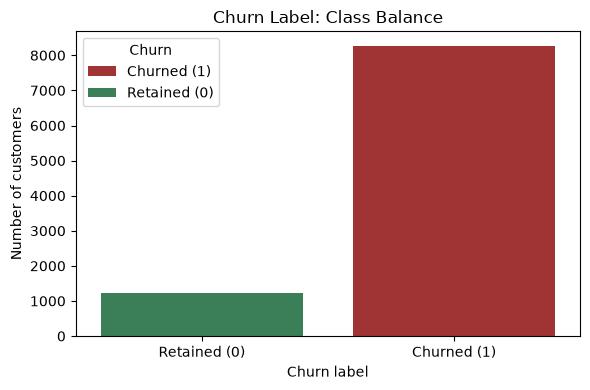

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = churn_df['Churn'].map({0: 'Retained (0)', 1: 'Churned (1)'})
sns.countplot(x=labels, hue=labels, palette={'Retained (0)': 'seagreen', 'Churned (1)': 'firebrick'},
              order=['Retained (0)', 'Churned (1)'], legend=True, ax=ax)
ax.set_title('Churn Label: Class Balance')
ax.set_xlabel('Churn label')
ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.show()

### Step 1 Observations
- **Cut-off date:** 2024-11-01. There are **9,488 customers** with at least one order before it.
- **Churn rate: 87.2%.** Churn is the majority class. This follows from how rarely customers order: about 2 orders each in 24 months, a median gap of 142 days between orders, and only 24% of repeat orders placed within 60 days.
- **What this means:** a model that predicts churn for everyone would already be right 87% of the time, with an F1 of about 0.93. The PRD target (F1 ≥ 0.70) can therefore be met without the model learning anything. For this reason, Step 3 includes a **Dummy baseline** and uses **ROC-AUC** to pick the best model.

## Step 2: Features

All features are calculated per customer using **only orders on or before the cut-off**.

| Group | Feature | Definition |
|---|---|---|
| Recency / Frequency / Monetary | `RecencyDays` | Days from the last order to the cut-off |
| | `TenureDays` | Days from the first order to the cut-off |
| | `OrderCount` | Number of orders |
| | `AvgOrderValue` | Mean `FinalAmount` per order |
| Delivery experience | `LateRate` | Share of orders `Delivered Late` |
| | `FailedOrderRate` | Share of orders `Cancelled` or `Food Not Delivered` |
| | `AvgDeliveryTime` | Mean delivery time of delivered orders |
| Feedback | `AvgRating` | Mean of Customer, Delivery and Food rating |
| | `NegativeFeedbackRate` | Share of reviews with `Negative` sentiment |
| Promotions / Payment | `CouponUsageRate` | Share of orders with a discount |
| | `CODShare` | Share of orders paid by Cash On Delivery |
| Ordering habits | `PeakHourShare`, `WeekendShare` | Share of orders in peak hours / on weekends |
| Profile | `Age`, `Gender`, `Membership` | From `customers` |
| | `Region` | From `cities` via the customer's city |

`TotalSpend` is also kept in the table, but only for the RFM segments in Step 5. It is not a model feature, because it is simply `OrderCount × AvgOrderValue`.

### Data decisions
- **`RegistrationDate` is not used.** 42% of customers have a registration date *after* their first order, so tenure is measured from the first order instead.
- **`TotalOrders` from `customers` is not used.** It does not match the number of orders in the orders table.
- **Delivery time only for delivered orders.** Cancelled orders also carry a delivery time in the data, which would distort the average.
- **Missing values are filled inside the model pipeline** (median for numbers, most frequent value for categories), so the fill values come from the training data only.

### 2.1 Missing values

In [8]:
missing = churn_df.isna().mean().mul(100).round(1)
missing[missing > 0].rename('Missing %').to_frame()

,Missing %
AvgDeliveryTime,18.4
AvgRating,16.5
NegativeFeedbackRate,16.5


- `AvgRating`, `NegativeFeedbackRate`: the customer never left a review
- `AvgDeliveryTime` : none of the customer's orders were delivered (all cancelled / not delivered)

### 2.2 Summary statistics

In [9]:
churn_df[CANDIDATE_NUMERIC].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
RecencyDays,9488.0,251.61,182.35,0.0,95.00,217.00,384.00,670.0
TenureDays,9488.0,420.50,182.69,0.0,285.00,457.00,578.00,670.0
OrderCount,9488.0,1.98,1.08,1.0,1.00,2.00,3.00,8.0
AvgOrderValue,9488.0,392.09,131.62,33.0,303.34,386.31,472.05,976.3
LateRate,9488.0,0.10,0.25,0.0,0.00,0.00,0.00,1.0
FailedOrderRate,9488.0,0.34,0.38,0.0,0.00,0.25,0.50,1.0
AvgDeliveryTime,7739.0,39.27,16.58,8.0,30.00,36.50,45.00,180.0
AvgRating,7926.0,3.52,1.08,1.0,2.67,3.67,4.50,5.0
NegativeFeedbackRate,7926.0,0.25,0.38,0.0,0.00,0.00,0.50,1.0
CouponUsageRate,9488.0,0.35,0.39,0.0,0.00,0.33,0.60,1.0


### 2.3 Checking for redundant features
If two features are highly correlated (|r| > 0.8), they carry the same information. Keeping both makes the Logistic Regression coefficients and the feature importances harder to read, so we keep only one of the pair.

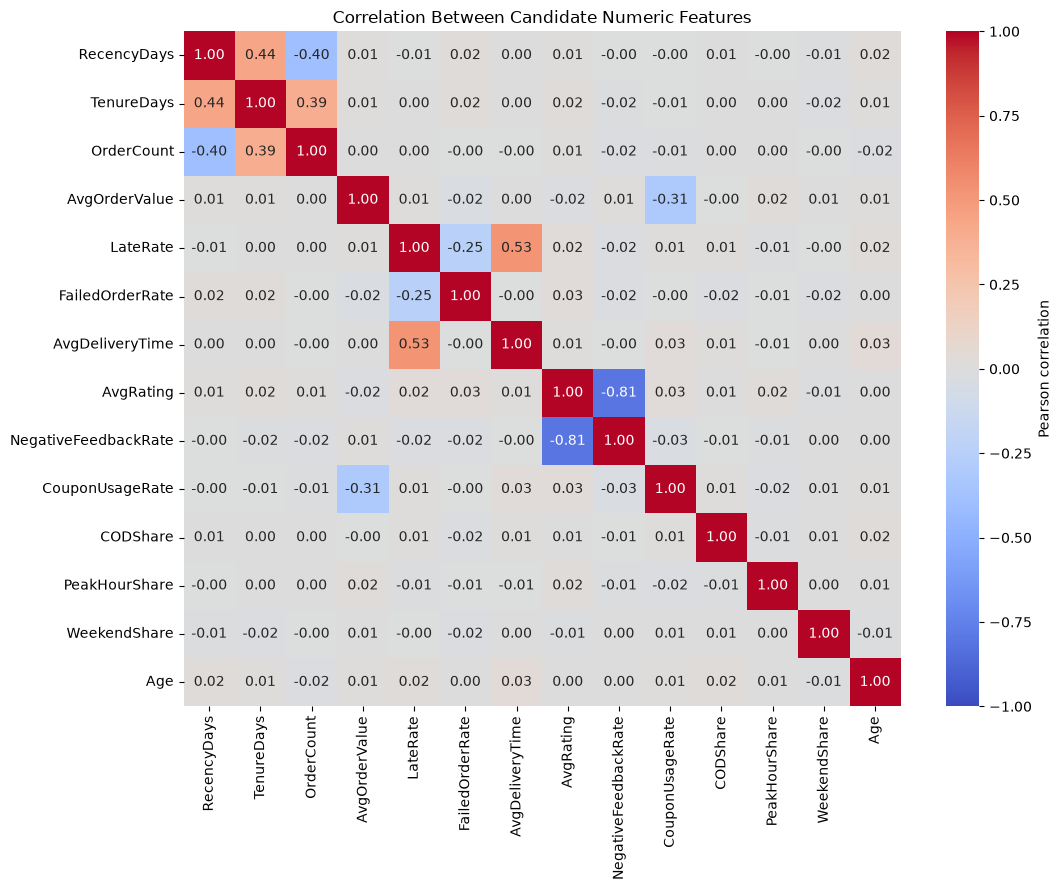

Pairs with |r| > 0.8:
AvgRating  NegativeFeedbackRate    0.81
dtype: float64


In [10]:
corr = churn_df[CANDIDATE_NUMERIC].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Correlation Between Candidate Numeric Features')
plt.tight_layout()
plt.show()

pairs = corr.abs().where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print("Pairs with |r| > 0.8:")
print(pairs[pairs > 0.8].round(2))

`AvgRating` and `NegativeFeedbackRate` are strongly related (a low rating usually comes with a negative review). We keep **`AvgRating`**, since it is the easier one to explain, and drop `NegativeFeedbackRate`. No other pair is above 0.8.

**Final model features:**

In [11]:
print(f"Numeric ({len(NUMERIC_FEATURES)}):", NUMERIC_FEATURES)
print(f"Categorical ({len(CATEGORICAL_FEATURES)}):", CATEGORICAL_FEATURES)

Numeric (13): ['RecencyDays', 'TenureDays', 'OrderCount', 'AvgOrderValue', 'LateRate', 'FailedOrderRate', 'AvgDeliveryTime', 'AvgRating', 'CouponUsageRate', 'CODShare', 'PeakHourShare', 'WeekendShare', 'Age']
Categorical (3): ['Gender', 'Membership', 'Region']


### 2.4 Churned vs retained customers
A useful feature should have a clearly different average for churned and retained customers.

In [12]:
group_means = churn_df.groupby('Churn')[NUMERIC_FEATURES].mean().T
group_means.columns = ['Retained (0)', 'Churned (1)']
group_means['Difference %'] = (
    (group_means['Churned (1)'] - group_means['Retained (0)']) / group_means['Retained (0)'] * 100
).round(1)
group_means.round(3)

,Retained (0),Churned (1),Difference %
RecencyDays,249.433,251.925,1.0
TenureDays,411.539,421.819,2.5
OrderCount,1.945,1.989,2.3
AvgOrderValue,385.813,393.015,1.9
LateRate,0.113,0.103,-8.4
FailedOrderRate,0.348,0.337,-3.0
AvgDeliveryTime,39.840,39.189,-1.6
AvgRating,3.560,3.519,-1.1
CouponUsageRate,0.371,0.352,-5.1
CODShare,0.170,0.167,-1.8


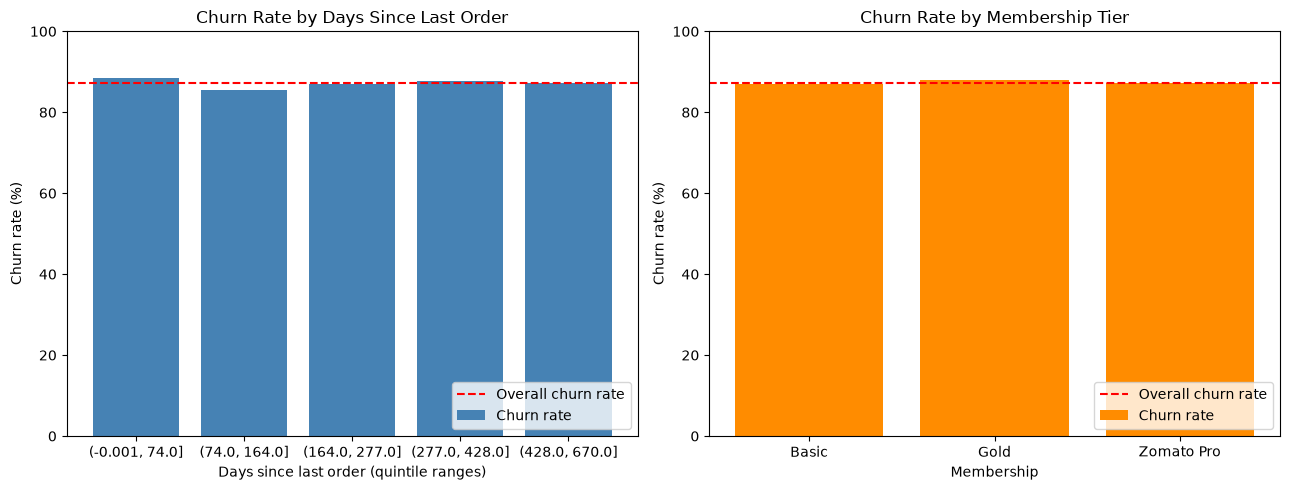

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

recency_bucket = pd.qcut(churn_df['RecencyDays'], 5)
recency_churn = churn_df.groupby(recency_bucket, observed=True)['Churn'].mean() * 100
axes[0].bar(recency_churn.index.astype(str), recency_churn.values, color='steelblue', label='Churn rate')
axes[0].axhline(churn_df['Churn'].mean() * 100, color='red', linestyle='--', label='Overall churn rate')
axes[0].set_title('Churn Rate by Days Since Last Order')
axes[0].set_xlabel('Days since last order (quintile ranges)')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_ylim(0, 100)
axes[0].legend(loc='lower right')

membership_churn = churn_df.groupby('Membership')['Churn'].mean() * 100
axes[1].bar(membership_churn.index, membership_churn.values, color='darkorange', label='Churn rate')
axes[1].axhline(churn_df['Churn'].mean() * 100, color='red', linestyle='--', label='Overall churn rate')
axes[1].set_title('Churn Rate by Membership Tier')
axes[1].set_xlabel('Membership')
axes[1].set_ylabel('Churn rate (%)')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Step 2 Observations
- **Final feature set:** 13 numeric and 3 categorical features. `NegativeFeedbackRate` was dropped because it overlaps with `AvgRating` (r = 0.81).
- **Churned and retained customers look almost the same.** Every numeric feature differs by less than ±9% between the two groups. The largest gaps are `LateRate` (−8.4%), `WeekendShare` (−5.6%) and `CouponUsageRate` (−5.1%), and all the others are within ±3%. The `LateRate` gap even goes the "wrong" way: retained customers had slightly *more* late orders.
- **Recency and membership make no difference.** Churn stays between 85% and 88% in every recency group, from customers who ordered in the last 74 days to those whose last order was over a year before the cut-off. It is also about the same for Basic, Gold and Zomato Pro members. In real food-delivery data, recency is usually the strongest churn signal.
- **Expectation for Step 3:** the models will find very little to learn from these features.

## Step 3: Model Training

**Train/test split:** 80/20, stratified on `Churn` so both sets have the same churn rate. Since there is one row per customer, the same customer cannot end up in both sets.

**Pipeline** (the same for every model):
- Numeric: median imputation → `StandardScaler`
- Categorical: most-frequent imputation → `OneHotEncoder`

**Models:**
| Model | Settings |
|---|---|
| Dummy (always churn) | Always predicts the majority class. This is the baseline every model must beat. |
| Logistic Regression | `class_weight='balanced'` |
| Decision Tree | `max_depth=5`, `class_weight='balanced'` |
| Random Forest | 300 trees, `max_depth=8`, `class_weight='balanced'` |
| Gradient Boosting | default settings, balanced `sample_weight` |

**Class imbalance:** churn is the *majority* class (~87%), so the minority class is "retained". Without any correction, a model can simply predict "churn" for everyone. We use **class weighting** (`class_weight='balanced'`, or balanced sample weights for Gradient Boosting, which has no `class_weight` option). This makes mistakes on the smaller class cost more. We chose it over resampling (e.g. SMOTE) because it needs no extra library and does not create synthetic rows.

In [14]:
X_train, X_test, y_train, y_test = split_data(churn_df)

print("Train:", X_train.shape, f"| churn rate {y_train.mean():.1%}")
print("Test :", X_test.shape, f"| churn rate {y_test.mean():.1%}")

Train: (7590, 16) | churn rate 87.2%
Test : (1898, 16) | churn rate 87.1%


In [15]:
comparison, fitted_models = train_and_compare(X_train, X_test, y_train, y_test)
comparison

,Accuracy,Precision,Recall,F1,F1 (Retained),ROC-AUC
Model,,,,,,
Dummy (always churn),0.871,0.871,1.000,0.931,0.000,0.500
Logistic Regression,0.527,0.878,0.531,0.662,0.214,0.515
Decision Tree,0.356,0.900,0.293,0.442,0.237,0.544
Random Forest,0.726,0.877,0.796,0.835,0.187,0.537
Gradient Boosting,0.612,0.883,0.640,0.742,0.220,0.528


- **F1** here is for the churn class. The Dummy model gets the highest F1 (0.93) without learning anything, just because 87% of customers churn. So F1 alone cannot be used to choose a model on this data.
- **F1 (Retained)** shows how well a model finds the customers who *do* come back. The Dummy model scores 0 here.
- **ROC-AUC** measures how well the model ranks churners above non-churners at any threshold. 0.5 means no better than random guessing. We choose the best model using **ROC-AUC**.

In [16]:
best_name = pick_best_model(comparison)
best_model = fitted_models[best_name]
print("Best model by ROC-AUC:", best_name)

Best model by ROC-AUC: Decision Tree


### 3.1 Is the result stable?
The test set has about 1,900 customers, so a small gap from 0.5 in ROC-AUC could simply be luck. We run a 5-fold cross-validation on the training set to check.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name in ['Logistic Regression', 'Decision Tree', 'Random Forest']:
    pipe = Pipeline([('prep', build_preprocessor()), ('model', get_models()[name])])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = {'CV ROC-AUC mean': scores.mean(), 'CV ROC-AUC std': scores.std()}

pd.DataFrame(cv_results).T.round(3)

,CV ROC-AUC mean,CV ROC-AUC std
Logistic Regression,0.491,0.012
Decision Tree,0.517,0.018
Random Forest,0.496,0.016


### Step 3 Observations
- **Every model is close to random** (ROC-AUC 0.515–0.544 on the test set, where 0.5 = random).
- **The best model on the test set is the Decision Tree (ROC-AUC 0.544).** However, cross-validation shows this lead is not stable: the Decision Tree averages 0.517 (± 0.018) across 5 folds, and Logistic Regression and Random Forest fall slightly *below* 0.5. The small gap over 0.5 is noise from one particular split, not a real pattern.
- **F1 for the churn class** ranges from 0.44 to 0.84 across the models, all below the Dummy baseline's 0.93. Class weighting makes the models predict "retained" more often, which lowers churn recall. This is the expected trade-off when the minority class is given more weight.
- **Conclusion:** with these features, whether a customer orders in the next 60 days cannot be predicted better than chance. The dataset appears to be synthetic, with orders placed at random times, which would explain this.

## Step 4: Evaluation of the Best Model

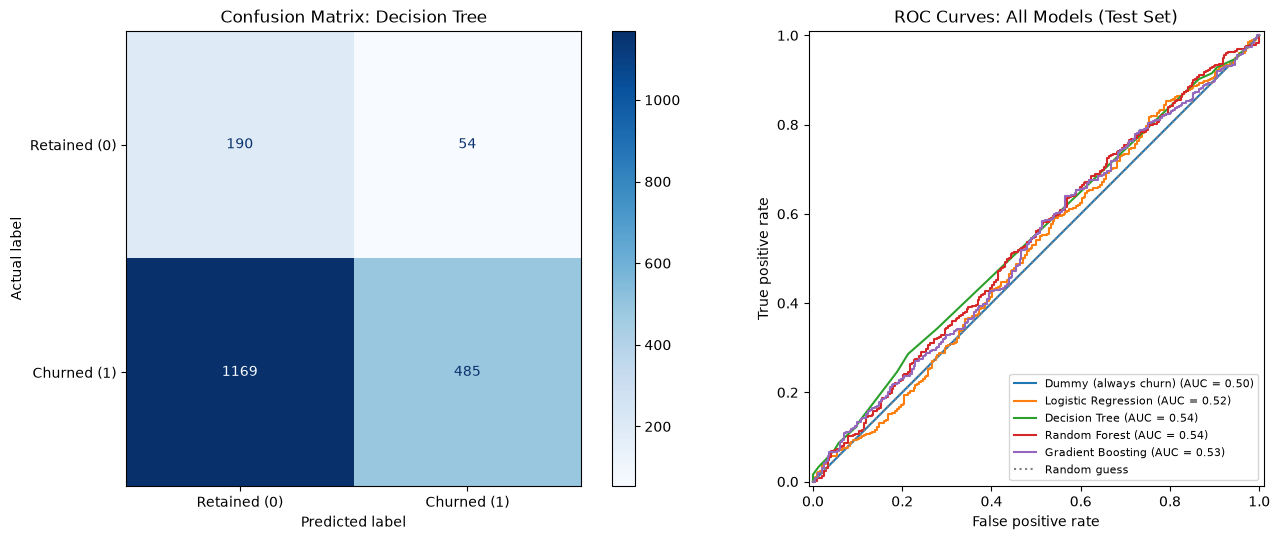

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test,
                                      display_labels=['Retained (0)', 'Churned (1)'],
                                      cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix: {best_name}')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('Actual label')

for name, pipe in fitted_models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], color='grey', linestyle=':', label='Random guess')
axes[1].set_title('ROC Curves: All Models (Test Set)')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

### 4.1 Top 10 churn drivers
We use **permutation importance**: shuffle one feature at a time on the test set and measure how much the ROC-AUC drops. A large drop means the model depends on that feature. This works the same way for any model, and it scores each original feature (for example, `Region` as a whole rather than each one-hot column).

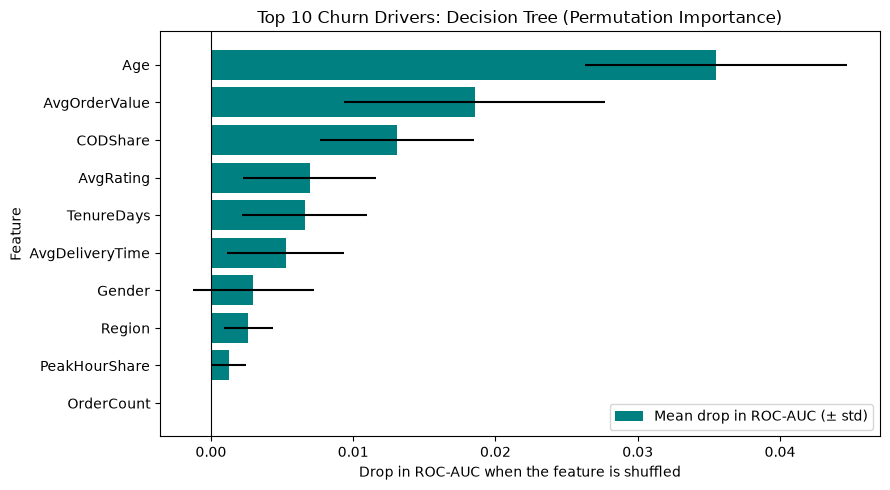

,Feature,Importance,Std
0,Age,0.0355,0.0092
1,AvgOrderValue,0.0186,0.0092
2,CODShare,0.0131,0.0054
3,AvgRating,0.0069,0.0047
4,TenureDays,0.0066,0.0044
5,AvgDeliveryTime,0.0053,0.0041
6,Gender,0.0030,0.0042
7,Region,0.0026,0.0017
8,PeakHourShare,0.0013,0.0012
9,OrderCount,0.0000,0.0000


In [19]:
top_drivers = get_top_drivers(best_model, X_test, y_test, top_n=10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_drivers['Feature'][::-1], top_drivers['Importance'][::-1],
        xerr=top_drivers['Std'][::-1], color='teal', label='Mean drop in ROC-AUC (± std)')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top 10 Churn Drivers: {best_name} (Permutation Importance)')
ax.set_xlabel('Drop in ROC-AUC when the feature is shuffled')
ax.set_ylabel('Feature')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

top_drivers.round(4)

### Step 4 Observations
- **Confusion matrix (Decision Tree, test set):** 190 of the 244 retained customers are correctly identified, but only 485 of the 1,654 churners are caught (recall 0.29). The balanced class weights push the model towards predicting "retained".
- **ROC curves:** all models stay close to the diagonal (random guess) line.
- **Top drivers:** `Age`, `AvgOrderValue` and `CODShare` rank highest. However, shuffling any one of them lowers the ROC-AUC by only 0.01–0.04, and the model itself is only slightly better than random. These should **not** be presented to stakeholders as real reasons for churn. They are the splits the tree happened to pick in this sample.

### 4.2 Churn probability for every customer
Each customer gets a churn probability from the best model and a risk band based on fixed cut-offs:
- **Low:** probability ≤ 0.4
- **Medium:** 0.4 to 0.6
- **High:** above 0.6

The model is trained with balanced class weights, so 0.5 is its decision point, and the Medium band covers the uncertain area around it. Fixed cut-offs are easy to explain on the dashboard, and customers with the same probability always fall in the same band.

`InTestSet = 1` marks the customers the model did not see during training.

In [20]:
test_ids = churn_df.loc[X_test.index, 'CustomerID']
churn_scores = score_customers(best_model, churn_df, test_ids)
print(churn_scores['RiskSegment'].value_counts())
churn_scores.head()

RiskSegment
Medium    7889
High      1057
Low        542
Name: count, dtype: int64


,CustomerID,Churn,ChurnProbability,RiskSegment,InTestSet,R,F,M,RFM_Segment
0,1,1,0.590498,Medium,0,1,1,3,Lost
1,2,1,0.483117,Medium,1,2,2,4,At Risk
2,3,1,0.590498,Medium,1,5,2,4,Loyal
3,6,1,0.483117,Medium,0,3,3,4,Loyal
4,7,1,0.590498,Medium,0,1,1,3,Lost


Does the risk band match reality? On the **test set only** (customers the model never saw), the actual churn rate should rise from Low to High if the model works.

In [21]:
churn_scores[churn_scores['InTestSet'] == 1].groupby('RiskSegment', observed=True).agg(
    Customers=('CustomerID', 'size'),
    AvgProbability=('ChurnProbability', 'mean'),
    ActualChurnRate=('Churn', 'mean'),
).round(3)

,Customers,AvgProbability,ActualChurnRate
RiskSegment,,,
Low,100,0.290,0.870
Medium,1569,0.500,0.868
High,229,0.808,0.895


## Step 5: RFM Segments

The RFM segments are rule-based. They don't depend on the model, and they are easy to explain to the marketing team. Each customer gets three scores from 1 to 5 at the cut-off date:
- **R (Recency):** quintiles of `RecencyDays`; more recent means a higher score
- **F (Frequency):** `OrderCount` used directly: 1, 2, 3, 4, 5+ orders. Quintiles don't work here because most customers have only 1–2 orders.
- **M (Monetary):** quintiles of `TotalSpend`

Segments are assigned in this order (the first rule that matches wins):

| Segment | Rule | Meaning |
|---|---|---|
| Champions | R ≥ 4 and F ≥ 3 | Ordered recently and often |
| Loyal | R ≥ 3 and F ≥ 2 | Fairly recent repeat customers |
| New | R ≥ 4 and F = 1 | Recent first-time customers |
| At Risk | R ≤ 2 and F ≥ 2 | Used to order repeatedly, not seen for a while |
| Lost | R ≤ 2 and F = 1 | One order, long ago |
| Needs Attention | anything else | Middle recency, single order |

In [22]:
rfm_summary = churn_scores.groupby('RFM_Segment').agg(
    Customers=('CustomerID', 'size'),
    AvgRecencyScore=('R', 'mean'),
    AvgFrequencyScore=('F', 'mean'),
    AvgMonetaryScore=('M', 'mean'),
    ActualChurnRate=('Churn', 'mean'),
).sort_values('Customers', ascending=False)
rfm_summary.round(2)

,Customers,AvgRecencyScore,AvgFrequencyScore,AvgMonetaryScore,ActualChurnRate
RFM_Segment,,,,,
Loyal,2583,3.76,2.31,3.61,0.88
Lost,2321,1.37,1.00,1.72,0.88
Champions,1517,4.55,3.53,4.62,0.87
At Risk,1465,1.71,2.38,3.70,0.87
New,959,4.45,1.00,1.67,0.85
Needs Attention,643,3.00,1.00,1.69,0.86


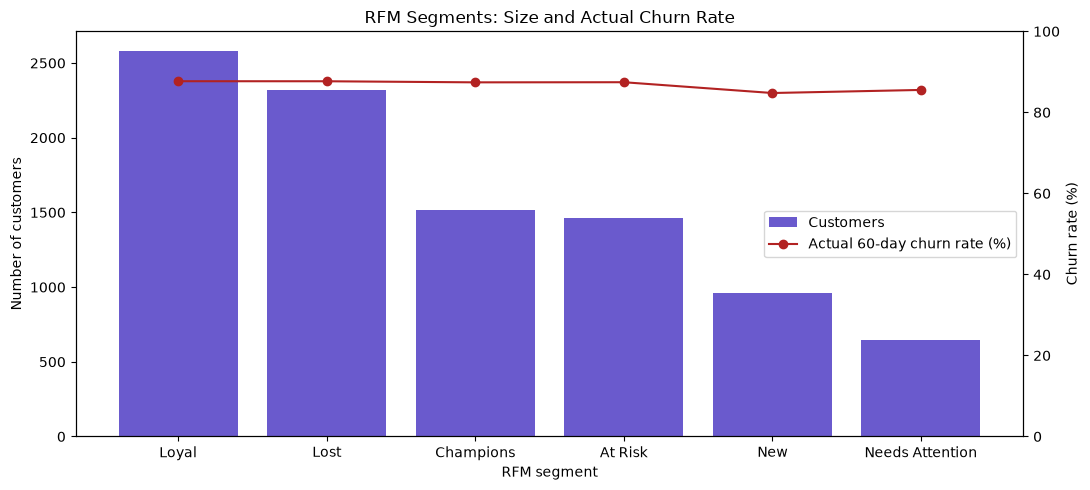

In [23]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(rfm_summary.index, rfm_summary['Customers'], color='slateblue', label='Customers')
ax1.set_xlabel('RFM segment')
ax1.set_ylabel('Number of customers')

ax2 = ax1.twinx()
ax2.plot(rfm_summary.index, rfm_summary['ActualChurnRate'] * 100, color='firebrick', marker='o',
         label='Actual 60-day churn rate (%)')
ax2.set_ylabel('Churn rate (%)')
ax2.set_ylim(0, 100)

handles = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
names = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(handles, names, loc='center right')
ax1.set_title('RFM Segments: Size and Actual Churn Rate')
plt.tight_layout()
plt.show()

### Step 5 Observations
- The segments separate customers well by **value and engagement**: Champions have the highest R, F and M scores, while Lost customers have a single order made long ago.
- However, the actual 60-day churn rate is **85–88% in every segment**. Even Champions churn at the same rate as Lost customers. This confirms the Step 3 finding: past ordering behaviour does not tell us who will order in the next 60 days.
- The segments are still useful for **deciding who to target and how much to spend** (for example, protecting high-value Champions and Loyal customers first). They should not be used to predict *who will churn*.

## Saving Outputs
- `models/churn_best_model.pkl`: the full pipeline (preprocessing + best model). It can be applied directly to a new customer table.
- `data/processed/churn_scores.csv`: churn probability, risk band and RFM segment for every customer (used by the Power BI ML and Customer Analytics pages)
- `data/processed/churn_dataset.parquet`: the modelling table

In [24]:
save_outputs(best_model, churn_scores, churn_df)

Saved models/churn_best_model.pkl, data/processed/churn_scores.csv (9488 customers) and data/processed/churn_dataset.parquet


Check: reload the saved model and confirm it reproduces the saved test-set probabilities.

In [25]:
reloaded = joblib.load('../models/churn_best_model.pkl')
saved = pd.read_csv('../data/processed/churn_scores.csv').set_index('CustomerID')

reloaded_prob = reloaded.predict_proba(X_test)[:, 1]
saved_prob = saved.loc[churn_df.loc[X_test.index, 'CustomerID'], 'ChurnProbability'].to_numpy()
print("Reloaded model matches saved scores:", np.allclose(reloaded_prob, saved_prob))

Reloaded model matches saved scores: True


## Summary and Recommendations

### PRD checklist (Section 24.2)
| Requirement | Status |
|---|---|
| Binary 60-day churn label from recency/frequency | Done: cut-off date approach with no leakage |
| At least 3 classifiers compared (LR, DT, RF, GB) | Done: 4 models plus a Dummy baseline |
| Class imbalance handled and documented | Done: `class_weight='balanced'` / balanced sample weights |
| Accuracy, Precision, Recall, F1, ROC/AUC, confusion matrix | Done |
| Top 10 churn drivers | Done: permutation importance, with the caveat above |
| Churn probability for every test customer | Done: `churn_scores.csv` (`InTestSet = 1`) |
| Saved model | Done: `models/churn_best_model.pkl` |
| F1 ≥ 0.70 | Met by Random Forest (0.84) and Gradient Boosting (0.74), but the Dummy baseline scores 0.93, so F1 is not a meaningful target on this data |

### Key finding
Churn is the normal behaviour on this platform (87% of customers placed no order in the 60 days after the cut-off). None of the available features (recency, frequency, spend, delivery experience, ratings, coupons, payment, profile) separate churners from non-churners. The best model scores ROC-AUC ≈ 0.52 in cross-validation, which is effectively random. This result is reported as it is instead of being tuned upwards: a model that looks accurate here would either be predicting the majority class or leaking future information.

### Recommendations for Growth Marketing
1. **Treat retention as the default problem.** With 87% of customers not reordering within 60 days, broad re-engagement (e.g. a reminder or offer about 30–45 days after an order) is likely to work better than trying to single out individual churners.
2. **Prioritise by customer value, not predicted churn.** Use the RFM segments to decide where to spend retention budget: Champions and Loyal first, then At Risk customers with high M scores.
3. **Collect better behavioural signals.** App sessions, searches, cart abandonment and complaint tickets are usually much stronger churn predictors than order history alone.
4. **Revisit the churn window.** With a median reorder gap of 142 days, a 60-day window marks most normal customers as churned. A 90–180-day window would match actual ordering behaviour better.

### Limitations and future improvements
- Profile fields (`Membership`, `City`) are single current values, not values at the cut-off date.
- Feedback has no timestamp, so reviews are assumed to be given right after the order.
- Possible extensions: several monthly cut-off dates for more training rows, hyperparameter tuning, probability calibration, and a longer churn window.